# Classical Baselines: TF-IDF + Logistic Regression / Linear SVM

The first two of five approaches. These are here to answer a simple question: how much can a bag-of-words model do on its own, before we bother with anything sequence-aware (`bilstm.ipynb`, `cnn_bigru_attention.ipynb`, `distilbert_finetuned.ipynb`)? The EDA (finding #10) already showed all three classes share the same core vocabulary, so we'd expect these baselines to struggle a bit relative to the sequential models — that comparison is itself one of the more interesting results.

Metrics: macro-F1 as the main one (the classes are imbalanced — finding #1), plus accuracy, per-class precision/recall, and a confusion matrix.


In [1]:
import sys
sys.path.append('../src')
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from preprocessing import LABEL_TO_IDX, CLASS_NAMES
from eval_utils import evaluate

train_df = pd.read_csv('../data/processed/train_split.csv')
val_df = pd.read_csv('../data/processed/val_split.csv')
print(train_df.shape, val_df.shape)
train_df.head(3)


(8205, 6) (1449, 6)


,tweet_id,safe_text,label,agreement,clean_text,label_idx
0,RW6ZG1JK,Is there a link between the measles outbreak a...,-1,0.333333,Is there a link between the measles outbreak a...,0
1,VQ3YE878,"""Vaccinations cause autism"" - very very stupid...",1,1.000000,"""Vaccinations cause autism"" - very very stupid...",2
2,WE4PVO3Q,"“<user> On average, ppl who complain live long...",0,1.000000,"“<user> On average, ppl who complain live long...",1


## TF-IDF vectorization
Word 1-2 grams, `min_df=2` to drop the hyper-rare singleton tokens (EDA finding #8), capped at the top 20k features.

In [2]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=20000, sublinear_tf=True)
X_train = vectorizer.fit_transform(train_df['clean_text'])
X_val = vectorizer.transform(val_df['clean_text'])

y_train = train_df['label'].map(LABEL_TO_IDX).values
y_val = val_df['label'].map(LABEL_TO_IDX).values

print('Vocabulary size:', len(vectorizer.vocabulary_))
print(X_train.shape, X_val.shape)


Vocabulary size: 18431
(8205, 18431) (1449, 18431)


## Approach 1: TF-IDF + Logistic Regression
Class-weighted, since EDA finding #1 showed Negative is only 10.4% of the data.

In [3]:
logreg = LogisticRegression(max_iter=2000, class_weight='balanced', C=1.0, random_state=42)
logreg.fit(X_train, y_train)
val_preds_lr = logreg.predict(X_val)
result_lr = evaluate(y_val, val_preds_lr, 'TFIDF_LogisticRegression')



=== TFIDF_LogisticRegression ===
Macro-F1: 0.6747  Weighted-F1: 0.7328  Accuracy: 0.7267
              precision    recall  f1-score   support

    Negative       0.44      0.62      0.51       154
     Neutral       0.83      0.76      0.79       704
    Positive       0.72      0.72      0.72       591

    accuracy                           0.73      1449
   macro avg       0.66      0.70      0.67      1449
weighted avg       0.74      0.73      0.73      1449



## Approach 2: TF-IDF + Linear SVM
Same features, a different kind of classifier (max-margin instead of probabilistic), trained to see whether the classifier itself matters here or just the representation.

In [4]:
svm = LinearSVC(class_weight='balanced', C=1.0, random_state=42, max_iter=5000)
svm.fit(X_train, y_train)
val_preds_svm = svm.predict(X_val)
result_svm = evaluate(y_val, val_preds_svm, 'TFIDF_LinearSVM')



=== TFIDF_LinearSVM ===
Macro-F1: 0.6652  Weighted-F1: 0.7309  Accuracy: 0.7315
              precision    recall  f1-score   support

    Negative       0.51      0.45      0.48       154
     Neutral       0.81      0.77      0.79       704
    Positive       0.70      0.76      0.73       591

    accuracy                           0.73      1449
   macro avg       0.67      0.66      0.67      1449
weighted avg       0.73      0.73      0.73      1449



## ROC and Precision-Recall curves
One-vs-rest curves per class. Logistic Regression gives real class probabilities; Linear SVM doesn't have `predict_proba` by design (it optimizes a margin, not a likelihood), so we use its `decision_function` scores instead — still valid for ranking purposes even though they're not calibrated probabilities. Worth having given the class imbalance (finding #1), since a confusion matrix alone doesn't show how well-separated the scores are across thresholds.


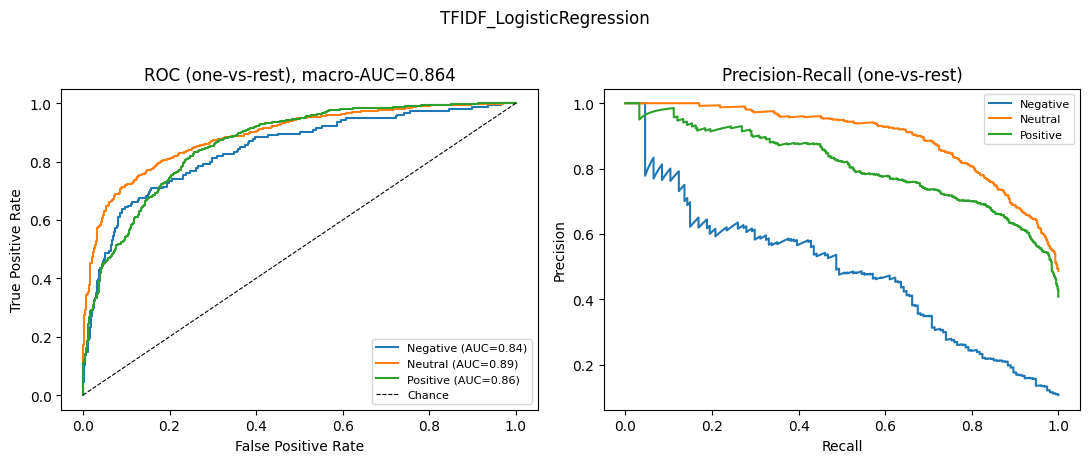

LogReg macro-AUC: 0.8644


In [5]:
from eval_utils import plot_roc_pr

proba_lr = logreg.predict_proba(X_val)
auc_lr = plot_roc_pr(y_val, proba_lr, 'TFIDF_LogisticRegression')
print('LogReg macro-AUC:', round(auc_lr, 4))


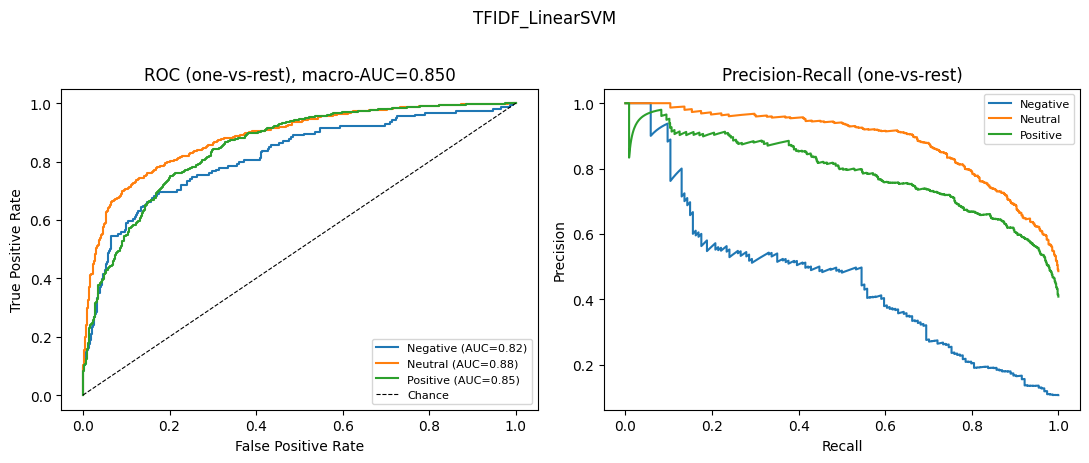

Linear SVM macro-AUC: 0.8497


In [6]:
scores_svm = svm.decision_function(X_val)
auc_svm = plot_roc_pr(y_val, scores_svm, 'TFIDF_LinearSVM')
print('Linear SVM macro-AUC:', round(auc_svm, 4))


## Most predictive features (Logistic Regression coefficients)
Quick sanity check: do the top features per class match what we saw in the EDA word clouds (`autism`/`cause` skewing Negative, `science`/`safe` skewing Positive)?


In [7]:
import numpy as np
feature_names = np.array(vectorizer.get_feature_names_out())
for idx, cls in enumerate(CLASS_NAMES):
    top_idx = np.argsort(logreg.coef_[idx])[-15:][::-1]
    print(f"\nTop features for {cls}:")
    print(', '.join(feature_names[top_idx]))



Top features for Negative:
cdcwhistleblower, vaccines, vaccine, autism, mercury, vaccinations, never, forced, proof, fda, vaccinate my, my, truth, aluminum, brain

Top features for Neutral:
measles, mmr, immunity, the measles, disneyland, state, have measles, ebola, new, county, disney, she, immunity and, measles at, information

Top features for Positive:
vaccinate, vaccineswork, kids, vaccinateyourkids, anti, get, vaccinated, your, children, preventable, today, not cause, child, immunization, vaccination


## Summary

Both baselines are saved to `reports/results/TFIDF_LogisticRegression.json` and `reports/results/TFIDF_LinearSVM.json`, with confusion matrices in `figures/`. These numbers feed into the comparison table in `notebooks/results_comparison.ipynb`.
